In [17]:
import scipy.io as sio

import contextlib
from tqdm import tqdm
import joblib
from joblib import Parallel, delayed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from pathlib import Path
from scipy import stats
from scipy.interpolate import interp1d
from matplotlib.path import Path as mPath

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

from statsmodels.stats.multitest import multipletests
from sklearn.covariance import LedoitWolf

from utils import get_itr_index, index_to_type, load_data


In [18]:
def extract_ab_ba(data: dict, ana_tt, ana_bt):

    data_AB = []
    data_BA = []
    
    for index in get_itr_index(ana_tt, ana_bt):
        
        tt_idx, bt_idx = index
        fr = data["firing"][tt_idx][bt_idx]
        if fr is None:
            continue
        
        tt, _ = index_to_type(tt_idx, bt_idx)
        
        if "CAB" in tt or "ACB" in tt or "ABC" in tt:
            data_AB.append(fr)
        elif "CBA" in tt or "BCA" in tt or "BAC" in tt:
            data_BA.append(fr)
        else:
            raise ValueError("Trial type not recognized:", tt)
    
    data_AB = np.concatenate(data_AB, axis=1)
    data_BA = np.concatenate(data_BA, axis=1)

    return data_AB, data_BA


In [19]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_cb = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_cb
        tqdm_object.close()

In [20]:
def _task_score_decode(task, X_all, labels, perm_labels, splits, C, max_iter):
    """
    task = (shuffle_idx, fold_idx)
    return: (shuffle_idx, fold_idx, scores)  scores shape (n_time,)
    """
    shuffle_idx, fold_idx = task
    y = labels if shuffle_idx < 0 else perm_labels[shuffle_idx]

    train_idx, test_idx = splits[fold_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    n_time = X_all.shape[2]
    scores = np.empty(n_time, dtype=float)

    for t in range(n_time):
        X_t = X_all[:, :, t].T
        X_train, X_test = X_t[train_idx], X_t[test_idx]

        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", LinearSVC(C=C, max_iter=max_iter))
        ])
        clf.fit(X_train, y_train)
        scores[t] = float(clf.score(X_test, y_test))

    return (shuffle_idx, fold_idx, scores)


def decode_and_shuffle(
    data_AB, data_BA,
    n_splits=5, n_repeats=10,
    n_shuffles=500,
    n_jobs=64,
    random_state=0,
    backend="threading",
    C=1.0,
    max_iter=20000,
):
    rng = np.random.RandomState(random_state)

    neurons, n_AB, n_time = data_AB.shape
    _, n_BA, _ = data_BA.shape

    X_all = np.concatenate([data_AB, data_BA], axis=1)  # (neurons, n_trials, n_time)
    labels = np.concatenate([
        np.ones(n_AB, dtype=int),
        np.zeros(n_BA, dtype=int)
    ])  # (n_trials,)

    n_trials = labels.size

    # repeated stratified CV (keeps class ratios)
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state
    )
    splits = list(cv.split(np.zeros(n_trials), labels))
    n_folds = len(splits)

    # pre-generate permuted labels
    perm_labels = np.empty((n_shuffles, n_trials), dtype=int)
    for i in range(n_shuffles):
        perm_labels[i] = rng.permutation(labels)

    tasks = []
    for fold_idx in range(n_folds):
        tasks.append((-1, fold_idx))
    for i_shuf in range(n_shuffles):
        for fold_idx in range(n_folds):
            tasks.append((i_shuf, fold_idx))

    total_tasks = len(tasks)

    pbar = tqdm(total=total_tasks, desc="Shuffle & Decode", dynamic_ncols=True)
    with tqdm_joblib(pbar):
        results = Parallel(n_jobs=n_jobs, backend=backend, inner_max_num_threads=1, batch_size="auto")(
            delayed(_task_score_decode)(task, X_all, labels, perm_labels, splits, C, max_iter)
            for task in tasks
        )

    # aggregate
    scores_real = np.zeros((n_folds, n_time), dtype=float)
    scores_shuffle = np.zeros((n_shuffles, n_folds, n_time), dtype=float)

    for shuf_idx, fold_idx, scores in results:
        if shuf_idx < 0:
            scores_real[fold_idx, :] = scores
        else:
            scores_shuffle[shuf_idx, fold_idx, :] = scores

    mean_acc = np.mean(scores_real, axis=0)
    sem_acc  = np.std(scores_real, axis=0, ddof=1) / np.sqrt(n_folds)

    # shuffle: take mean across folds for each shuffle
    shuffle_means = np.mean(scores_shuffle, axis=1)  # (n_shuffles, n_time)
    shuffle_lower = np.percentile(shuffle_means, 2.5, axis=0)
    shuffle_upper = np.percentile(shuffle_means, 97.5, axis=0)

    # cluster stats (1D over time): same as your original
    sig_mask = mean_acc > shuffle_upper
    clusters = []
    current = None
    for i, v in enumerate(sig_mask):
        if v:
            if current is None:
                current = [i, i]
            else:
                current[1] = i
        else:
            if current is not None:
                clusters.append(tuple(current))
                current = None
    if current:
        clusters.append(tuple(current))

    real_cluster_stats = []
    for start_idx, end_idx in clusters:
        stat = np.sum(mean_acc[start_idx:end_idx+1] - shuffle_upper[start_idx:end_idx+1])
        real_cluster_stats.append((start_idx, end_idx, stat))

    null_cluster_stats = []
    for i in range(n_shuffles):
        perm = shuffle_means[i]
        perm_mask = perm > shuffle_upper
        c = None
        for j, v in enumerate(perm_mask):
            if v:
                if c is None:
                    c = [j, j]
                else:
                    c[1] = j
            else:
                if c is not None:
                    mass = np.sum(perm[c[0]:c[1]+1] - shuffle_upper[c[0]:c[1]+1])
                    null_cluster_stats.append(mass)
                    c = None
        if c:
            mass = np.sum(perm[c[0]:c[1]+1] - shuffle_upper[c[0]:c[1]+1])
            null_cluster_stats.append(mass)

    null_cluster_stats = np.array(null_cluster_stats, dtype=float)

    cluster_signif = []
    for start_idx, end_idx, stat in real_cluster_stats:
        pval = (np.sum(null_cluster_stats >= stat) + 1) / (len(null_cluster_stats) + 1)
        cluster_signif.append((start_idx, end_idx, pval))

    return mean_acc, sem_acc, shuffle_lower, shuffle_upper, cluster_signif


def _task_tgm_chunk(task, X, y, splits, time_idx, C, max_iter):
    """
    task = (fold_idx, chunk_start, chunk_end)
    X: (n_trials, n_neurons, n_time)
    time_idx: (T,) list of used time indices
    return: (fold_idx, chunk_start, rows) rows shape (chunk_len, T)
    """
    fold_idx, cs, ce = task
    train_idx, test_idx = splits[fold_idx]

    y_train = y[train_idx]
    y_test  = y[test_idx]
    T = len(time_idx)

    # test data for all t_test once: (T, n_test, n_neurons)
    X_test_all = X[test_idx][:, :, time_idx]          # (n_test, n_neurons, T)
    X_test_all = np.transpose(X_test_all, (2, 0, 1))  # (T, n_test, n_neurons)

    rows = np.empty((ce - cs, T), dtype=float)

    for ii, t_train in enumerate(time_idx[cs:ce]):
        # TRAIN at one time
        X_train = X[train_idx, :, t_train]  # (n_train, n_neurons)

        # fit scaler ONLY on training to avoid leakage :contentReference[oaicite:5]{index=5}
        scaler = StandardScaler(with_mean=True, with_std=True)
        X_train_z = scaler.fit_transform(X_train)

        mean = scaler.mean_
        scale = scaler.scale_.copy()
        scale[scale == 0] = 1.0

        clf = LinearSVC(C=C, max_iter=max_iter)
        clf.fit(X_train_z, y_train)

        w = clf.coef_.ravel()
        b = float(clf.intercept_[0])

        # standardize all test times in one shot: (T, n_test, n_neurons)
        Xz = (X_test_all - mean[None, None, :]) / scale[None, None, :]

        # decision scores: (T, n_test)
        scores = np.tensordot(Xz, w, axes=([2], [0])) + b

        pred = (scores > 0).astype(int)
        acc  = (pred == y_test[None, :]).mean(axis=1)  # (T,)
        rows[ii, :] = acc

    return fold_idx, cs, rows


def temporal_generalization(
    data_AB, data_BA,
    n_splits=5, n_repeats=10,
    n_jobs=64,
    random_state=0,
    backend="threading",
    C=1.0,
    max_iter=20000,
    chunk_size=10,
):
    data_AB = np.asarray(data_AB, dtype=float)
    data_BA = np.asarray(data_BA, dtype=float)
    n_neurons, n_AB, n_time = data_AB.shape
    _, n_BA, n_time2 = data_BA.shape
    if n_time2 != n_time:
        raise ValueError("data_AB and data_BA must have same n_time")

    X_all = np.concatenate([data_AB, data_BA], axis=1)  # (n_neurons, n_trials, n_time)
    y = np.concatenate([np.zeros(n_AB, int), np.ones(n_BA, int)])
    n_trials = y.size

    # reshape to (n_trials, n_neurons, n_time)
    X = X_all.transpose(1, 0, 2)

    time_idx = np.arange(0, n_time, dtype=int)
    T = len(time_idx)

    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state
    )
    splits = list(cv.split(np.zeros(n_trials), y))
    n_folds = len(splits)

    # tasks: (fold, chunk_start, chunk_end)
    tasks = []
    for fold_idx in range(n_folds):
        for cs in range(0, T, chunk_size):
            ce = min(cs + chunk_size, T)
            tasks.append((fold_idx, cs, ce))

    pbar = tqdm(total=len(tasks), desc="TGM", dynamic_ncols=True)
    with tqdm_joblib(pbar):
        results = Parallel(n_jobs=n_jobs, backend=backend)(
            delayed(_task_tgm_chunk)(task, X, y, splits, time_idx, C, max_iter)
            for task in tasks
        )

    # aggregate across folds using sum & sumsq
    sum_mat = np.zeros((T, T), dtype=float)
    sumsq_mat = np.zeros((T, T), dtype=float)

    for fold_idx, cs, rows in results:
        ce = cs + rows.shape[0]
        sum_mat[cs:ce, :] += rows
        sumsq_mat[cs:ce, :] += rows * rows

    tgm_mean = sum_mat / n_folds

    if n_folds > 1:
        var = (sumsq_mat - (sum_mat * sum_mat) / n_folds) / (n_folds - 1)
        var = np.maximum(var, 0.0)
        tgm_sem = np.sqrt(var / n_folds)
    else:
        tgm_sem = np.zeros_like(tgm_mean)

    return tgm_mean, tgm_sem


# mean_acc, sem_acc, shuf_lo, shuf_hi, clusters = decode_and_shuffle(
#     data_AB, data_BA,
#     n_splits=5, n_repeats=10,
#     n_shuffles=100,
#     n_jobs=12,
#     backend="threading",   # or "loky"
#     random_state=0
# )
#
# tgm_mean, tgm_sem, time_idx = temporal_generalization_no_perm(
#     data_AB, data_BA,
#     n_splits=5, n_repeats=10,
#     n_jobs=12,
#     backend="threading",
#     time_stride=1,
#     chunk_size=10
# )


In [21]:
def plot_decoding_with_zones(data: dict, mean_acc, sem_acc, shuffle_lower, shuffle_upper, cluster_signif, space_unit=2.0):

    n_time = len(mean_acc)
    X = np.arange(n_time)

    zones_color = {
        1: "#1f77b4",
        3: "#1f77b4",
    }
    acc_color = "#2ca02c"


    plt.figure(figsize=(6, 3))
    ax = plt.gca()

    # mean + sem
    ax.plot(X, mean_acc, color=acc_color)
    ax.fill_between(X, mean_acc - sem_acc, mean_acc + sem_acc, color=acc_color, alpha=0.4)

    # shuffle band
    ax.fill_between(X, shuffle_lower, shuffle_upper, color="gray", alpha=0.4)

    # chance line
    ax.axhline(0.5, linestyle="--", color="k")

    # cluster significance highlight
    for start, end, p in cluster_signif:
        if p < 0.05:
            ax.axvspan(start, end, facecolor="black", alpha=0.2)

    # zones background (horizontal bars)
    x0, x1 = ax.get_xlim()
    eps = 0.002 * (x1 - x0)
    h_frac = 0.05

    zones = data["zones"]

    for zi, row in enumerate(zones):

        if zi not in zones_color: continue

        start_x = np.floor(row[0])
        end_x   = np.ceil(row[1])

        ax.axvline(start_x, linestyle="--", color="k", linewidth=1)
        ax.axvline(end_x,   linestyle="--", color="k", linewidth=1)

        color_zone = zones_color[zi]

        # rect = Rectangle(
        #     (start_x - eps, 1.0 - h_frac),
        #     end_x - start_x + 2*eps, h_frac,
        #     transform=ax.get_xaxis_transform(),
        #     facecolor=color_zone,
        #     edgecolor="none",
        #     clip_on=False,
        #     zorder=6,
        # )
        # ax.add_patch(rect)

    # aesthetics
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Position (cm)", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{x * space_unit:g}")
    )
    ax.tick_params(labelsize=12)
    plt.tight_layout()
    plt.show()


def plot_tgm_heatmap(
    data: dict,
    tgm_mean: np.ndarray,
    *,
    vmin: float | None = None,
    vmax: float | None = None,
    show_diag: bool = True,
    show_zones: bool = True,
    space_unit: float = 2.0,
):

    tgm_mean = np.asarray(tgm_mean, dtype=float)
    if tgm_mean.ndim != 2 or tgm_mean.shape[0] != tgm_mean.shape[1]:
        raise ValueError("tgm_mean must be a square 2D array (T, T)")
    T = tgm_mean.shape[0]

    time_idx = np.arange(T, dtype=float)

    coord = time_idx
    xlabel = "Test position (cm)"
    ylabel = "Train position (cm)"
    tick_formatter = mticker.FuncFormatter(lambda x, pos: f"{x:g}")

    if T > 1:
        d = float(coord[1] - coord[0])
    else:
        d = 1.0
    extent = [coord[0] - d/2, coord[-1] + d/2, coord[0] - d/2, coord[-1] + d/2]

    chance = 0.5
    if vmin is None or vmax is None:
        dev = np.nanmax(np.abs(tgm_mean - chance))
        if not np.isfinite(dev) or dev == 0:
            dev = 0.05
        if vmin is None:
            vmin = chance - dev
        if vmax is None:
            vmax = chance + dev
    
    fig = plt.figure(figsize=(6, 5))
    ax = fig.gca()
    title = "Temporal generalization"
    cbar_labels = "Score"

    cmap = "viridis"
    im = ax.imshow(
        tgm_mean,
        origin="lower",
        extent=extent,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )

    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")
    ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, pos: f"{x * space_unit:g}")
    )
    ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, pos: f"{x * space_unit:g}")
    )
    if tick_formatter is not None:
        ax.xaxis.set_major_formatter(tick_formatter)
        ax.yaxis.set_major_formatter(tick_formatter)

    if show_diag:
        ax.plot([coord[0], coord[-1]], [coord[0], coord[-1]], linestyle="--", linewidth=0.8, color="k", alpha=0.6)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_labels, fontsize=11)

    zones = data["zones"]
    zones_color = {
        1: "#1f77b4",
        3: "#1f77b4",
    }

    if show_zones and zones is not None and len(zones) > 0:

        for zi, row in enumerate(zones):

            if zi not in zones_color: continue

            start_x = row[0]
            end_x   = row[1]

            ax.axvline(start_x, linestyle="--", color="k", linewidth=0.8)
            ax.axvline(end_x,   linestyle="--", color="k", linewidth=0.8)
            ax.axhline(start_x, linestyle="--", color="k", linewidth=0.8)
            ax.axhline(end_x,   linestyle="--", color="k", linewidth=0.8)

    plt.tight_layout()
    plt.show()

In [22]:
# file_path = "../../data/HPC_2p/HP07/neuro_type_saveHP07_15_2025-03-08.mat"

# data = load_data(file_path)
# data_AB, data_BA = extract_ab_ba(data, ana_tt=["*"], ana_bt=["*"])

# print(data_AB.shape, data_BA.shape)

# mean_acc, sem_acc, shuf_lo, shuf_hi, clusters = decode_and_shuffle(data_AB, data_BA, backend="loky")
# plot_decoding_with_zones(data, mean_acc, sem_acc, shuf_lo, shuf_hi, clusters)
# tgm_mean, _ = temporal_generalization(data_AB, data_BA)
# plot_tgm_heatmap(data, tgm_mean, vmin=0.2, vmax=0.8)

In [23]:
# file_path = "../../data/HPC_2p/HP07/neuro_type_saveHP07_17_2025-03-11.mat"

# data = load_data(file_path)
# data_AB, data_BA = extract_ab_ba(data, ana_tt=["*"], ana_bt=["*"])

# print(data_AB.shape, data_BA.shape)

# mean_acc, sem_acc, shuf_lo, shuf_hi, clusters = decode_and_shuffle(data_AB, data_BA, backend="loky")
# plot_decoding_with_zones(data, mean_acc, sem_acc, shuf_lo, shuf_hi, clusters)
# tgm_mean, _ = temporal_generalization(data_AB, data_BA)
# plot_tgm_heatmap(data, tgm_mean, vmin=0.2, vmax=0.8)

In [24]:
def _clamp_slice(s: int, e: int, T: int) -> tuple[int, int]:
    s = int(s); e = int(e)
    s = max(0, min(s, T))
    e = max(0, min(e, T))
    return s, e

def extract_begin_position(
    data: dict,
    ana_tt: list,
    ana_bt: list,
):
    s1 = 0
    e1 = 10
    
    data_AB_list = []
    data_BA_list = []
    
    for index in get_itr_index(ana_tt, ana_bt):
        
        tt_idx, bt_idx = index
        fr = data["firing"][tt_idx][bt_idx]
        if fr is None:
            continue
        
        tt, _ = index_to_type(tt_idx, bt_idx)

        T = fr.shape[2]
        s1c, e1c = _clamp_slice(s1, e1, T)
        if (e1c <= s1c):
            continue

        fr_seg = fr[:, :, s1c:e1c]

        if ("CAB" in tt) or ("ACB" in tt) or ("ABC" in tt):
            data_AB_list.append(fr_seg)
        elif ("CBA" in tt) or ("BCA" in tt) or ("BAC" in tt):
            data_BA_list.append(fr_seg)
        else:
            raise ValueError(f"Trial type not recognized: {tt}")

    if (len(data_AB_list) == 0) or (len(data_BA_list) == 0):
        return None, None

    data_AB = np.concatenate(data_AB_list, axis=1)  # (neurons, nAB, L)
    data_BA = np.concatenate(data_BA_list, axis=1)  # (neurons, nBA, L)
    return data_AB, data_BA
        

def extract_ab_position(
    data: dict,
    ana_tt: list,
    ana_bt: list,
    *,
    extend_cm: float = 10.0,
):
    zones = data["zones"]
    zone1_idx = 1
    zone2_idx = 3

    # s1 = int(np.floor((zones[zone1_idx][0] - extend_cm)))
    # e1 = int(np.ceil ((zones[zone1_idx][1] + extend_cm)))
    # s2 = int(np.floor((zones[zone2_idx][0] - extend_cm)))
    # e2 = int(np.ceil ((zones[zone2_idx][1] + extend_cm)))
    
    s1 = int(np.floor((zones[zone1_idx][0])))
    e1 = int(np.ceil ((zones[zone1_idx + 1][0])))
    s2 = int(np.floor((zones[zone2_idx][0])))
    e2 = int(np.ceil ((zones[zone2_idx + 1][0])))

    data_AB_list = []
    data_BA_list = []
    
    for index in get_itr_index(ana_tt, ana_bt):
        
        tt_idx, bt_idx = index
        fr = data["firing"][tt_idx][bt_idx]
        if fr is None:
            continue
        
        tt, _ = index_to_type(tt_idx, bt_idx)

        T = fr.shape[2]
        s1c, e1c = _clamp_slice(s1, e1, T)
        s2c, e2c = _clamp_slice(s2, e2, T)
        if (e1c <= s1c) or (e2c <= s2c):
            continue

        seg1 = fr[:, :, s1c:e1c]
        seg2 = fr[:, :, s2c:e2c]
        fr_seg = np.concatenate([seg1, seg2], axis=2)  # (neurons, trials, L)

        if ("CAB" in tt) or ("ACB" in tt) or ("ABC" in tt):
            data_AB_list.append(fr_seg)
        elif ("CBA" in tt) or ("BCA" in tt) or ("BAC" in tt):
            data_BA_list.append(fr_seg)
        else:
            raise ValueError(f"Trial type not recognized: {tt}")

    if (len(data_AB_list) == 0) or (len(data_BA_list) == 0):
        return None, None

    data_AB = np.concatenate(data_AB_list, axis=1)  # (neurons, nAB, L)
    data_BA = np.concatenate(data_BA_list, axis=1)  # (neurons, nBA, L)
    return data_AB, data_BA


# =========================
# Fisher-vector + permutation + FDR
# =========================

def time_bin_mean(fr_seg, bin_size: int | None):
    if bin_size is None or bin_size <= 1:
        return fr_seg
    L = fr_seg.shape[2]
    L2 = (L // bin_size) * bin_size
    if L2 <= 0:
        return fr_seg
    x = fr_seg[:, :, :L2]
    x = x.reshape(x.shape[0], x.shape[1], L2 // bin_size, bin_size).mean(axis=3)
    return x


def _one_neuron_fisher_diag_perm(Xn_all, y, M, n_pos, n_neg, ridge=1e-6, eps=1e-12):
    """
    Xn_all: (n_trials, L)
    y: (n_trials,)
    M: (n_perm, n_trials) float32
    """
    X = Xn_all.astype(np.float64, copy=False)
    X2 = X * X

    total_sum = X.sum(axis=0)      # (L,)
    total_sum_sq = X2.sum(axis=0)  # (L,)

    Xpos = X[y == 1]
    Xneg = X[y == 0]
    if Xpos.shape[0] < 2 or Xneg.shape[0] < 2:
        return 0.0, 1.0

    mu_pos = Xpos.mean(axis=0)
    mu_neg = Xneg.mean(axis=0)
    delta = mu_pos - mu_neg

    var_pos = Xpos.var(axis=0, ddof=1)
    var_neg = Xneg.var(axis=0, ddof=1)
    sw = var_pos + var_neg + ridge
    stat_obs = float(np.sum((delta * delta) / (sw + eps)))

    # permutation：pos_sum = M @ X => (n_perm, L)
    pos_sum = M @ X
    pos_sum_sq = M @ X2

    neg_sum = total_sum[None, :] - pos_sum
    neg_sum_sq = total_sum_sq[None, :] - pos_sum_sq

    pos_mean = pos_sum / n_pos
    neg_mean = neg_sum / n_neg
    delta_p = pos_mean - neg_mean

    pos_var = (pos_sum_sq - (pos_sum * pos_sum) / n_pos) / max(n_pos - 1, 1)
    neg_var = (neg_sum_sq - (neg_sum * neg_sum) / n_neg) / max(n_neg - 1, 1)
    pos_var = np.maximum(pos_var, 0.0)
    neg_var = np.maximum(neg_var, 0.0)

    sw_p = pos_var + neg_var + ridge
    stat_null = np.sum((delta_p * delta_p) / (sw_p + eps), axis=1)

    p = (1.0 + np.sum(stat_null >= stat_obs)) / (len(stat_null) + 1.0)
    return stat_obs, p


def _fisher_vector_stat_lw(X0, X1, ridge=1e-6):
    mu0 = X0.mean(axis=0)
    mu1 = X1.mean(axis=0)
    delta = mu1 - mu0

    R0 = X0 - mu0
    R1 = X1 - mu1
    R = np.vstack([R0, R1])  # pooled residuals

    lw = LedoitWolf(assume_centered=True).fit(R)
    Sw = lw.covariance_.copy()
    L = Sw.shape[0]
    Sw.flat[::L + 1] += ridge

    z = np.linalg.solve(Sw, delta)
    return float(delta @ z)


def _one_neuron_fisher_lw_perm(Xn_all, y, perms, ridge=1e-6):
    X0 = Xn_all[y == 0]
    X1 = Xn_all[y == 1]
    if X0.shape[0] < 2 or X1.shape[0] < 2:
        return 0.0, 1.0

    obs = _fisher_vector_stat_lw(X0, X1, ridge=ridge)

    null = np.empty(len(perms), dtype=float)
    for i, yp in enumerate(perms):
        X0p = Xn_all[yp == 0]
        X1p = Xn_all[yp == 1]
        null[i] = _fisher_vector_stat_lw(X0p, X1p, ridge=ridge)

    p = (1.0 + np.sum(null >= obs)) / (len(null) + 1.0)
    return obs, p


def count_sig_neurons_fisher_vector(
    file_path,
    ana_tt,
    ana_bt,
    *,
    position_type="ab", # "ab" or "begin"
    extend_cm=10.0,
    n_perm=2000,
    alpha=0.05,
    seed=0,
    cov="diag",        # "diag" or "lw"
    ridge=1e-6,
    time_bin=5,        # 5~10
    n_jobs=8,
    backend="threading",
):
    rng = np.random.RandomState(seed)

    data = load_data(file_path)
    
    if position_type == "ab":
        data_AB, data_BA = extract_ab_position(data, ana_tt, ana_bt, extend_cm=extend_cm)
    elif position_type == "begin":
        data_AB, data_BA = extract_begin_position(data, ana_tt, ana_bt)
    else:
        raise ValueError("position_type must be 'ab' or 'begin'")
    
    if data_AB is None:
        return {"n_sig": 0, "n_neuron": 0, "p": None, "q": None, "sig_neuron_ids": []}

    data_AB = time_bin_mean(data_AB, time_bin)
    data_BA = time_bin_mean(data_BA, time_bin)

    n_neuron = data_AB.shape[0]
    nAB = data_AB.shape[1]
    nBA = data_BA.shape[1]

    y = np.concatenate([np.zeros(nAB, int), np.ones(nBA, int)])
    n_trials = y.size
    n_pos = int(y.sum())
    n_neg = int(n_trials - n_pos)
    if n_pos < 2 or n_neg < 2:
        return {"n_sig": 0, "n_neuron": n_neuron, "p": None, "q": None, "sig_neuron_ids": []}

    perm_idx = np.array([rng.permutation(n_trials) for _ in range(n_perm)], dtype=np.int32)
    y_perm = y[perm_idx]
    M = (y_perm == 1).astype(np.float32)

    perms = [y_perm[i, :] for i in range(n_perm)]

    def _task(neuron_id: int):
        Xn_all = np.vstack([data_AB[neuron_id, :, :], data_BA[neuron_id, :, :]])  # (n_trials, L)
        if cov == "diag":
            return _one_neuron_fisher_diag_perm(Xn_all, y, M, n_pos, n_neg, ridge=ridge)
        elif cov == "lw":
            return _one_neuron_fisher_lw_perm(Xn_all, y, perms, ridge=ridge)
        else:
            raise ValueError("cov must be 'diag' or 'lw'")

    with tqdm_joblib(tqdm(total=n_neuron, desc=f"neurons (fisher-{cov})",
                            leave=False, dynamic_ncols=True)):
        results = Parallel(n_jobs=n_jobs, backend=backend)(
            delayed(_task)(n) for n in range(n_neuron)
        )

    stat_obs = np.array([r[0] for r in results], dtype=float)
    pvals = np.array([r[1] for r in results], dtype=float)

    rej, qvals, _, _ = multipletests(pvals, alpha=alpha, method="fdr_bh")

    # Collect significant neuron IDs
    sig_neuron_ids = data["cell_ids"][rej]  # Extract the IDs of significant neurons

    return {
        "n_sig": int(rej.sum()),
        "n_neuron": n_neuron,
        "p": pvals,
        "q": qvals,
        "stat": stat_obs,
        "sig_mask": rej,
        "sig_neuron_ids": sig_neuron_ids.tolist(),  # Return the list of significant neuron IDs
        "cov": cov,
        "time_bin": time_bin,
    }
    

In [25]:
def test_max_firing_at_ab(
    file_path,
    ana_tt,
    ana_bt,
    *,
    extend_cm=0.0,
):
    data = load_data(file_path)
    
    zones = data["zones"]
    zone1_idx = 1
    zone2_idx = 3

    # s1 = int(np.floor((zones[zone1_idx][0] - extend_cm)))
    # e1 = int(np.ceil ((zones[zone1_idx][1] + extend_cm)))
    # s2 = int(np.floor((zones[zone2_idx][0] - extend_cm)))
    # e2 = int(np.ceil ((zones[zone2_idx][1] + extend_cm)))
    s1 = int(np.floor((zones[zone1_idx][0])))
    e1 = int(np.ceil ((zones[zone1_idx + 1][0])))
    s2 = int(np.floor((zones[zone2_idx][0])))
    e2 = int(np.ceil ((zones[zone2_idx + 1][0])))
    
    # all_rejs = []

    # for index in get_itr_index(ana_tt, ana_bt):
        
    #     tt_idx, bt_idx = index
    #     fr = data["firing"][tt_idx][bt_idx]
        
    #     if fr is None:
    #         continue

    #     fr = np.mean(fr, axis=1)  # average over trials: (neurons, time)
    #     whole_range_max = fr.max(axis=1)  # (neurons,)

    #     seg1_data = fr[:, s1:e1]
    #     seg2_data = fr[:, s2:e2]
    #     seg_max = np.maximum(seg1_data.max(axis=1), seg2_data.max(axis=1))  # (neurons,)

    #     rejs = (whole_range_max < 2 * seg_max)
            
    #     all_rejs.append(rejs)
        
    # all_rejs = np.array(all_rejs, dtype=bool)
    # final_rej = np.any(all_rejs, axis=0) # (neurons,)
    
    all_fr = []
    
    for index in get_itr_index(ana_tt, ana_bt):
        
        tt_idx, bt_idx = index
        fr = data["firing"][tt_idx][bt_idx]
        
        if fr is None:
            continue

        all_fr.append(fr)
        
    all_fr = np.concatenate(all_fr, axis=1)  # (neurons, n_trials, time)
    all_fr = np.mean(all_fr, axis=1)  # average over trials:
    whole_range_max = all_fr.max(axis=1)  # (neurons,)
    seg1_data = all_fr[:, s1:e1]
    seg2_data = all_fr[:, s2:e2]
    seg_max = np.maximum(seg1_data.max(axis=1), seg2_data.max(axis=1))  # (neurons,)
    final_rej = (whole_range_max < 1.05 * seg_max)
    
    neuron_ids = data["cell_ids"][final_rej]
    
    return neuron_ids
        

In [26]:
# file_path = "../../data/HPC_2p/HP02/neuro_type_saveHP02_2_2024-12-29.mat"

# res_flw1 = count_sig_neurons_fisher_vector(
#     file_path, ana_tt=["*"], ana_bt=["*"],
#     position_type="begin",
#     cov="lw", time_bin=5,
#     n_perm=1000, alpha=0.1,
#     n_jobs=10, backend="threading"
# )

# print(np.where(res_flw1["sig_mask"])[0])

In [27]:
# file_path = "../../data/HPC_2p/HP02/neuro_type_saveHP02_1_2024-12-23.mat"
# extend_cm = 0

# res_flw1 = count_sig_neurons_fisher_vector(
#     file_path, ana_tt=["*"], ana_bt=["*"],
#     cov="lw", time_bin=5, extend_cm=extend_cm,
#     n_perm=1000, alpha=0.01,
#     n_jobs=10, backend="threading"
# )

# mf_ids1 = test_max_firing_at_ab(
#     file_path, ana_tt=["*"], ana_bt=["Correct"],
#     extend_cm=extend_cm,
# )

# intersec1 = list(set(res_flw1['sig_neuron_ids']) & set(mf_ids1))


# print(f"Intersection of significant neurons neurons:{len(res_flw1['sig_neuron_ids'])} / {res_flw1['n_neuron']}")
# print(f"Intersection of significant neurons and max-firing neurons:{len(intersec1)} / {res_flw1['n_neuron']}")


In [28]:
# file_path = "../../data/HPC_2p/HP02/neuro_type_saveHP02_2_2024-12-29.mat"
# extend_cm = 0

# res_flw2 = count_sig_neurons_fisher_vector(
#     file_path, ana_tt=["*"], ana_bt=["*"],
#     cov="lw", time_bin=5, extend_cm=extend_cm,
#     n_perm=1000, alpha=0.01,
#     n_jobs=10, backend="threading"
# )

# mf_ids2 = test_max_firing_at_ab(
#     file_path, ana_tt=["*"], ana_bt=["*"],
#     extend_cm=extend_cm,
# )
# intersec2 = list(set(res_flw2['sig_neuron_ids']) & set(mf_ids2))

# print(f"Intersection of significant neurons neurons:{len(res_flw2['sig_neuron_ids'])} / {res_flw2['n_neuron']}")
# print(f"Intersection of significant neurons and max-firing neurons:{len(intersec2)} / {res_flw2['n_neuron']}")

In [29]:
def _corr_matrix_from_vectors(vectors, method="pearson"):
    X = np.stack(vectors, axis=0)  # (4, n_neurons)

    if method == "pearson":
        return np.corrcoef(X)

    elif method == "spearman":
        from scipy.stats import rankdata
        X = np.stack([rankdata(x) for x in X], axis=0)
        return np.corrcoef(X)

    else:
        raise ValueError("method must be 'pearson' or 'spearman'")


def compute_rule_corr_matrix(
    file_path,
    ana_tt,
    ana_bt,
    *,
    group_average="by_condition",
    method="pearson",
):
    """
    Compute 4x4 correlation matrix for A1, A2, B1, B2 population vectors.

    Original groups:
        AB_s1e1 -> A1
        BA_s2e2 -> A2
        BA_s1e1 -> B1
        AB_s2e2 -> B2
    """

    data = load_data(file_path)

    zones = data["zones"]
    s1 = int(np.floor(zones[1][0]))
    e1 = int(np.ceil(zones[2][0]))
    s2 = int(np.floor(zones[3][0]))
    e2 = int(np.ceil(zones[4][0]))

    def interval_mean(fr, start, end):
        T = fr.shape[2]
        start = max(0, min(T, start))
        end = max(0, min(T, end))

        if end <= start:
            return None

        return np.nanmean(fr[:, :, start:end], axis=2)  # (neurons, trials)

    cond_groups = {
        "AB_s1e1": [],
        "AB_s2e2": [],
        "BA_s1e1": [],
        "BA_s2e2": [],
    }

    trial_groups = {
        "AB_s1e1": [],
        "AB_s2e2": [],
        "BA_s1e1": [],
        "BA_s2e2": [],
    }

    for tt_idx, bt_idx in get_itr_index(ana_tt, ana_bt):
        fr = data["firing"][tt_idx][bt_idx]

        if fr is None:
            continue

        tt, _ = index_to_type(tt_idx, bt_idx)

        if "CAB" in tt or "ACB" in tt or "ABC" in tt:
            track = "AB"
        elif "CBA" in tt or "BCA" in tt or "BAC" in tt:
            track = "BA"
        else:
            raise ValueError(f"Trial type not recognized: {tt}")

        m_s1e1 = interval_mean(fr, s1, e1)  # (neurons, trials)
        m_s2e2 = interval_mean(fr, s2, e2)

        if m_s1e1 is not None and m_s1e1.shape[1] > 0:
            key = f"{track}_s1e1"
            trial_groups[key].append(m_s1e1)
            cond_groups[key].append(np.nanmean(m_s1e1, axis=1))

        if m_s2e2 is not None and m_s2e2.shape[1] > 0:
            key = f"{track}_s2e2"
            trial_groups[key].append(m_s2e2)
            cond_groups[key].append(np.nanmean(m_s2e2, axis=1))

    # Important:
    # This order maps to A1, A2, B1, B2.
    labels = ["AB_s1e1", "BA_s2e2", "BA_s1e1", "AB_s2e2"]

    vectors = {}

    for key in labels:
        if group_average == "by_condition":
            if len(cond_groups[key]) == 0:
                vectors[key] = None
            else:
                vectors[key] = np.nanmean(
                    np.stack(cond_groups[key], axis=0),
                    axis=0,
                )

        elif group_average == "by_trial":
            if len(trial_groups[key]) == 0:
                vectors[key] = None
            else:
                all_trials = np.concatenate(
                    trial_groups[key],
                    axis=1,
                )  # (neurons, total_trials)

                vectors[key] = np.nanmean(all_trials, axis=1)

        else:
            raise ValueError(
                "group_average must be 'by_condition' or 'by_trial'"
            )

    missing = [k for k in labels if vectors[k] is None]

    if len(missing) > 0:
        raise ValueError(f"These groups are empty or invalid: {missing}")

    corr = _corr_matrix_from_vectors(
        [vectors[k] for k in labels],
        method=method,
    )

    return {
        "labels": labels,
        "vectors": vectors,
        "corr": corr,
    }


RULE_LABEL_MAP = {
    "AB_s1e1": "A1",
    "BA_s2e2": "A2",
    "BA_s1e1": "B1",
    "AB_s2e2": "B2",
}


def _display_rule_labels(labels):
    return [RULE_LABEL_MAP.get(l, l) for l in labels]


def _upper_tri_offdiag(mat):
    idx = np.triu_indices_from(mat, k=1)
    return mat[idx]


def _zscore_1d(x, eps=1e-12):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmean(x)) / (np.nanstd(x) + eps)


def make_pure_pattern_position_matrices(labels):
    """
    Construct pure-pattern and pure-position template matrices.

    Parameters
    ----------
    labels : list of str
        Should be ["A1", "A2", "B1", "B2"].

    Returns
    -------
    pure_pattern : ndarray
        Same pattern = 1, different pattern = 0.

    pure_position : ndarray
        Same position = 1, different position = 0.
    """

    patterns = [lab[0] for lab in labels]
    positions = [lab[1:] for lab in labels]

    pure_pattern = np.equal.outer(patterns, patterns).astype(float)
    pure_position = np.equal.outer(positions, positions).astype(float)

    return pure_pattern, pure_position


def compute_pattern_position_value(
    result,
    *,
    value_type="standardized_beta",
    fit_intercept=True,
):
    """
    Compute pattern value and position value from a 4x4 correlation matrix.

    Only off-diagonal values are used.

    value_type
    ----------
    "standardized_beta":
        Z-score observed corr and templates first, then regress.
        This gives dimensionless template-matching coefficients.

    "raw_beta":
        Direct regression on raw correlation values.
        This measures absolute similarity gain.

    "template_corr":
        Direct correlation between observed matrix and each pure template.

    Model for beta methods
    ----------------------
        corr_offdiag =
            intercept
            + pattern_value * pure_pattern_offdiag
            + position_value * pure_position_offdiag
    """

    corr = result["corr"]
    labels = _display_rule_labels(result["labels"])

    pure_pattern, pure_position = make_pure_pattern_position_matrices(labels)

    y = _upper_tri_offdiag(corr)
    x_pattern = _upper_tri_offdiag(pure_pattern)
    x_position = _upper_tri_offdiag(pure_position)

    valid = (
        np.isfinite(y)
        & np.isfinite(x_pattern)
        & np.isfinite(x_position)
    )

    y = y[valid]
    x_pattern = x_pattern[valid]
    x_position = x_position[valid]

    if value_type == "raw_beta":
        y_fit = y.copy()
        xp_fit = x_pattern.copy()
        xq_fit = x_position.copy()

        X = np.column_stack([xp_fit, xq_fit])

        if fit_intercept:
            X = np.column_stack([np.ones(len(y_fit)), X])

        beta = np.linalg.lstsq(X, y_fit, rcond=None)[0]

        if fit_intercept:
            intercept = float(beta[0])
            pattern_value = float(beta[1])
            position_value = float(beta[2])
        else:
            intercept = 0.0
            pattern_value = float(beta[0])
            position_value = float(beta[1])

    elif value_type == "standardized_beta":
        y_fit = _zscore_1d(y)
        xp_fit = _zscore_1d(x_pattern)
        xq_fit = _zscore_1d(x_position)

        X = np.column_stack([xp_fit, xq_fit])

        if fit_intercept:
            X = np.column_stack([np.ones(len(y_fit)), X])

        beta = np.linalg.lstsq(X, y_fit, rcond=None)[0]

        if fit_intercept:
            intercept = float(beta[0])
            pattern_value = float(beta[1])
            position_value = float(beta[2])
        else:
            intercept = 0.0
            pattern_value = float(beta[0])
            position_value = float(beta[1])

    elif value_type == "template_corr":
        pattern_value = float(np.corrcoef(y, x_pattern)[0, 1])
        position_value = float(np.corrcoef(y, x_position)[0, 1])
        intercept = np.nan

    else:
        raise ValueError(
            "value_type must be 'standardized_beta', 'raw_beta', or 'template_corr'"
        )

    return {
        "labels": labels,
        "value_type": value_type,
        "pattern_value": pattern_value,
        "position_value": position_value,
        "intercept": intercept,
        "pure_pattern": pure_pattern,
        "pure_position": pure_position,
        "observed_offdiag": y,
        "pattern_template_offdiag": x_pattern,
        "position_template_offdiag": x_position,
    }


def plot_rule_corr_matrix(
    result,
    rule_name,
    *,
    values=None,
    figsize=(5.2, 4.8),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annotate=True,
):
    corr = result["corr"]
    labels = _display_rule_labels(result["labels"])

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        corr,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    if annotate:
        for i in range(corr.shape[0]):
            for j in range(corr.shape[1]):
                ax.text(
                    j,
                    i,
                    f"{corr[i, j]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=12,
                )

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("correlation", fontsize=12)

    if values is None:
        title = f"{rule_name} correlation matrix"
    else:
        title = (
            f"{rule_name} correlation matrix\n"
            f"pattern value = {values['pattern_value']:.3f}, "
            f"position value = {values['position_value']:.3f}"
        )

    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_template_matrices(
    labels=("A1", "A2", "B1", "B2"),
    *,
    figsize=(8.0, 3.6),
    cmap="Greys",
):
    """
    Optional helper for checking pure pattern and pure position matrices.
    """

    pure_pattern, pure_position = make_pure_pattern_position_matrices(labels)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    mats = [pure_pattern, pure_position]
    titles = ["Pure pattern template", "Pure position template"]

    for ax, mat, title in zip(axes, mats, titles):
        im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=1)

        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels)
        ax.set_yticklabels(labels)

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax.text(
                    j,
                    i,
                    f"{mat[i, j]:.0f}",
                    ha="center",
                    va="center",
                    fontsize=11,
                )

        ax.set_title(title)

    plt.tight_layout()
    plt.show()


def _find_rule_file(
    dir_path,
    rule_suffix,
    *,
    extensions=(".mat", ".pkl", ".pickle", ".npz"),
):
    """
    Find one file whose stem ends with the given suffix.

    Example
    -------
    xxx_pattern.mat
    xxx_position.mat
    """

    dir_path = Path(dir_path)
    rule_suffix = rule_suffix.lower()

    candidates = []

    for file in dir_path.iterdir():
        if not file.is_file():
            continue

        if file.suffix.lower() not in extensions:
            continue

        if file.stem.lower().endswith(rule_suffix):
            candidates.append(file)

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"No file ending with '{rule_suffix}' found in {dir_path}"
        )

    if len(candidates) > 1:
        names = [p.name for p in candidates]
        raise ValueError(
            f"More than one file ending with '{rule_suffix}' found in {dir_path}: {names}"
        )

    return candidates[0]


def analyze_rule_corr_dir(
    dir_path,
    *,
    ana_tt=("ABC", "ACB", "BAC", "BCA", "CAB", "CBA"),
    ana_bt=("Correct",),
    group_average="by_trial",
    method="spearman",
    value_type="standardized_beta",
    plot=True,
    plot_templates=False,
):
    """
    Analyze one directory.

    The directory should contain:
        one file ending with 'pattern'
        one file ending with 'position'

    For each file:
        1. compute A1/A2/B1/B2 correlation matrix
        2. compute pattern value and position value
        3. optionally plot matrix

    Returns
    -------
    out : dict

    Main values:
        out["pattern"]["pattern_value"]
        out["pattern"]["position_value"]
        out["position"]["pattern_value"]
        out["position"]["position_value"]
    """

    dir_path = Path(dir_path)
    mouse_id = dir_path.name

    print(f"\n========== {mouse_id} ==========")

    if plot_templates:
        plot_template_matrices()

    pattern_file = _find_rule_file(dir_path, "pattern")
    position_file = _find_rule_file(dir_path, "position")

    files = {
        "pattern": pattern_file,
        "position": position_file,
    }

    out = {
        "mouse_id": mouse_id,
        "dir_path": str(dir_path),
        "value_type": value_type,
    }

    for rule_name, file_path in files.items():
        print(f"\n{rule_name.upper()} rule file: {file_path.name}")

        result = compute_rule_corr_matrix(
            file_path=file_path,
            ana_tt=list(ana_tt),
            ana_bt=list(ana_bt),
            group_average=group_average,
            method=method,
        )

        values = compute_pattern_position_value(
            result,
            value_type=value_type,
        )

        print(
            f"{rule_name.upper()} rule | "
            f"pattern value = {values['pattern_value']:.4f}, "
            f"position value = {values['position_value']:.4f}"
        )

        if value_type != "template_corr":
            print(f"intercept = {values['intercept']:.4f}")

        if plot:
            plot_rule_corr_matrix(
                result,
                rule_name=rule_name.capitalize(),
                # values=values,
            )

        out[rule_name] = {
            "file_path": str(file_path),
            "result": result,
            "values": values,
            "pattern_value": values["pattern_value"],
            "position_value": values["position_value"],
            "intercept": values["intercept"],
        }

    return out

In [30]:
def remove_top_right_spines(ax):
    """
    Remove top and right spines for cleaner plot.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def p_to_stars(p):
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "n.s."


def add_sig_bracket(ax, x1, x2, y, h, text, lw=1.2):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="k",
        lw=lw,
        clip_on=False,
    )
    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
    )


def paired_boxplot(
    ax,
    y1,
    y2,
    labels=("Group 1", "Group 2"),
    box_colors=("#bdbdbd", "#f0b35b"),
    point_colors=("k", "#c97c1f"),
    line_color="#555555",
    paired=True,
    tick_labelsize=15,
    axis_labelsize=15,
    box_width=0.42,
    line_gap=0.06,
):
    
    y1 = np.asarray(y1, float)
    y2 = np.asarray(y2, float)

    if paired:
        assert y1.size == y2.size, (
            "For paired boxplot, y1 and y2 must have the same length."
        )
        m = np.isfinite(y1) & np.isfinite(y2)
        y1, y2 = y1[m], y2[m]
        n = y1.size
    else:
        y1 = y1[np.isfinite(y1)]
        y2 = y2[np.isfinite(y2)]
        n = min(y1.size, y2.size)

    x1 = np.ones(y1.size)
    x2 = np.ones(y2.size) * 2

    box = ax.boxplot(
        [y1, y2],
        positions=[1, 2],
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="k", lw=2),
        boxprops=dict(edgecolor="k", lw=1.2),
        whiskerprops=dict(color="k", lw=1.2),
        capprops=dict(color="k", lw=1.2),
        capwidths=0.18,
    )

    for patch, color in zip(box["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    # ---------- Paired lines clipped to middle region ----------
    if paired:
        half_box = box_width / 2
        middle_x_start = 1 + half_box + line_gap
        middle_x_end = 2 - half_box - line_gap

        y_data_min = min(np.nanmin(y1), np.nanmin(y2))
        y_data_max = max(np.nanmax(y1), np.nanmax(y2))
        y_pad = (
            (y_data_max - y_data_min) * 0.1
            if y_data_max > y_data_min
            else 0.1
        )

        middle_y_min = y_data_min - y_pad
        middle_y_max = y_data_max + y_pad

        middle_rect_verts = [
            (middle_x_start, middle_y_min),
            (middle_x_end, middle_y_min),
            (middle_x_end, middle_y_max),
            (middle_x_start, middle_y_max),
            (middle_x_start, middle_y_min),
        ]

        middle_rect_codes = [
            mPath.MOVETO,
            mPath.LINETO,
            mPath.LINETO,
            mPath.LINETO,
            mPath.CLOSEPOLY,
        ]

        middle_clip_path = mPath(middle_rect_verts, middle_rect_codes)

        for i in range(y1.size):
            line = ax.plot(
                [x1[i], x2[i]],
                [y1[i], y2[i]],
                color=line_color,
                lw=1.0,
                alpha=0.65,
                zorder=1,
            )[0]

            line.set_clip_path(
                middle_clip_path,
                transform=ax.transData,
            )

    # ---------- Scatter ----------
    ax.scatter(
        x1,
        y1,
        s=36,
        color=point_colors[0],
        alpha=0.9,
        edgecolor="white",
        linewidth=0.6,
        zorder=3,
    )

    ax.scatter(
        x2,
        y2,
        s=36,
        color=point_colors[1],
        alpha=0.9,
        edgecolor="white",
        linewidth=0.6,
        zorder=3,
    )

    # ---------- Statistics ----------
    if paired:
        stat, p = stats.ttest_rel(y1, y2)
    else:
        stat, p = stats.ttest_ind(y1, y2)

    stars = p_to_stars(p)

    y_max = np.max([np.max(y1), np.max(y2)])
    y_min = np.min([np.min(y1), np.min(y2)])
    yr = y_max - y_min if y_max > y_min else 1.0

    y_br = y_max + 0.10 * yr

    add_sig_bracket(
        ax,
        1,
        2,
        y_br,
        0.04 * yr,
        stars,
    )

    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=tick_labelsize)

    ax.tick_params(
        axis="both",
        labelsize=tick_labelsize,
        width=1.2,
        length=4,
    )

    ax.xaxis.label.set_size(axis_labelsize)
    ax.yaxis.label.set_size(axis_labelsize)

    ax.set_xlim(0.5, 2.5)

    # Leave enough space for significance bracket
    ax.set_ylim(y_min - 0.12 * yr, y_max + 0.24 * yr)

    remove_top_right_spines(ax)

    return {
        "stat": stat,
        "p": p,
        "n": n,
        "stars": stars,
    }


def plot_rule_value_paired_comparison(
    df,
    *,
    value_name="pattern_value",
    figsize=(4.2, 5.0),
    title=None,
    ylabel=None,
):
    """
    Paired comparison between pattern rule and position rule.

    value_name
    ----------
    "pattern_value":
        Compare pattern_rule_pattern_value vs position_rule_pattern_value.

    "position_value":
        Compare pattern_rule_position_value vs position_rule_position_value.
    """

    if value_name == "pattern_value":
        y1 = df["pattern_rule_pattern_value"].to_numpy(float)
        y2 = df["position_rule_pattern_value"].to_numpy(float)

        default_ylabel = "Pattern value"

    elif value_name == "position_value":
        y1 = df["pattern_rule_position_value"].to_numpy(float)
        y2 = df["position_rule_position_value"].to_numpy(float)

        default_ylabel = "Position value"

    else:
        raise ValueError(
            "value_name must be 'pattern_value' or 'position_value'"
        )

    fig, ax = plt.subplots(figsize=figsize)

    stat_info = paired_boxplot(
        ax,
        y1,
        y2,
        labels=("Pattern rule", "Position rule"),
        box_colors=("#6ba3d6", "#f0b35b"),
        paired=True,
    )

    if title is not None:
        ax.set_title(title, fontsize=16)
    ax.set_ylabel(default_ylabel if ylabel is None else ylabel)

    plt.tight_layout()
    plt.show()

    print(
        f"{value_name}: paired t-test, "
        f"n = {stat_info['n']}, "
        f"t = {stat_info['stat']:.4f}, "
        f"p = {stat_info['p']:.3e}, "
        f"{stat_info['stars']}"
    )

    return stat_info


def analyze_all_mice_rule_corr(
    big_dir,
    *,
    ana_tt=("ABC", "ACB", "BAC", "BCA", "CAB", "CBA"),
    ana_bt=("Correct",),
    group_average="by_trial",
    method="spearman",
    value_type="standardized_beta",
    plot_each_matrix=False,
    skip_error=True,
):
    """
    Analyze all mouse folders under a larger directory.

    Each mouse folder should contain:
        one file ending with 'pattern'
        one file ending with 'position'

    Parameters
    ----------
    big_dir : str or Path
        Larger directory containing mouse subfolders.

    plot_each_matrix : bool
        Whether to plot correlation matrix for each mouse and each rule.

    skip_error : bool
        If True, skip problematic mouse folders.
        If False, raise error immediately.

    Returns
    -------
    df : pandas.DataFrame

    Columns
    -------
    mouse_id
    pattern_rule_pattern_value
    pattern_rule_position_value
    position_rule_pattern_value
    position_rule_position_value
    pattern_rule_intercept
    position_rule_intercept
    """

    big_dir = Path(big_dir)

    rows = []

    mouse_dirs = sorted([
        p for p in big_dir.iterdir()
        if p.is_dir()
    ])

    for mouse_dir in mouse_dirs:
        try:
            out = analyze_rule_corr_dir(
                mouse_dir,
                ana_tt=ana_tt,
                ana_bt=ana_bt,
                group_average=group_average,
                method=method,
                value_type=value_type,
                plot=plot_each_matrix,
                plot_templates=False,
            )

            row = {
                "mouse_id": out["mouse_id"],
                "dir_path": out["dir_path"],
                "value_type": value_type,

                "pattern_rule_pattern_value": out["pattern"]["pattern_value"],
                "pattern_rule_position_value": out["pattern"]["position_value"],

                "position_rule_pattern_value": out["position"]["pattern_value"],
                "position_rule_position_value": out["position"]["position_value"],

                "pattern_rule_intercept": out["pattern"]["intercept"],
                "position_rule_intercept": out["position"]["intercept"],

                "pattern_file": out["pattern"]["file_path"],
                "position_file": out["position"]["file_path"],
            }

            rows.append(row)

        except Exception as e:
            if skip_error:
                print(f"[Skipped] {mouse_dir.name}: {e}")
            else:
                raise e

    df = pd.DataFrame(rows)

    if len(df) == 0:
        raise ValueError(f"No valid mouse folders found under {big_dir}")

    return df


def plot_all_rule_value_comparisons(
    df,
):
    """
    Make two paired plots:
        1. pattern value: pattern rule vs position rule
        2. position value: pattern rule vs position rule
    """

    pattern_stats = plot_rule_value_paired_comparison(
        df,
        value_name="pattern_value",
        ylabel="Pattern similarity",
    )

    position_stats = plot_rule_value_paired_comparison(
        df,
        value_name="position_value",
        ylabel="Position similarity",
    )

    return {
        "pattern_value": pattern_stats,
        "position_value": position_stats,
    }


def analyze_and_plot_all_mice_rule_corr(
    big_dir,
    *,
    ana_tt=("ABC", "ACB", "BAC", "BCA", "CAB", "CBA"),
    ana_bt=("Correct",),
    group_average="by_trial",
    method="spearman",
    value_type="standardized_beta",
    plot_each_matrix=False,
    skip_error=True,
):
    """
    One-stop function.

    Returns
    -------
    df : pandas.DataFrame
        Summary values for all mice.

    stats_out : dict
        Paired t-test results for pattern value and position value.
    """

    df = analyze_all_mice_rule_corr(
        big_dir,
        ana_tt=ana_tt,
        ana_bt=ana_bt,
        group_average=group_average,
        method=method,
        value_type=value_type,
        plot_each_matrix=plot_each_matrix,
        skip_error=skip_error,
    )

    print("\n========== Summary ==========")
    print(df[
        [
            "mouse_id",
            "pattern_rule_pattern_value",
            "position_rule_pattern_value",
            "pattern_rule_position_value",
            "position_rule_position_value",
        ]
    ])

    stats_out = plot_all_rule_value_comparisons(
        df,
    )

    return df, stats_out

In [31]:
# out = analyze_rule_corr_dir(
#     "../../data/HPC_2p/HP07",
#     group_average="by_trial",
#     method="spearman",
#     value_type="standardized_beta",
#     plot=True,
# )


========== HP01 ==========

PATTERN rule file: neuro_type_saveHP01_1_2024-12-14_pattern.mat
PATTERN rule | pattern value = 0.9882, position value = 1.0048
intercept = 0.0000

POSITION rule file: neuro_type_saveHP01_1_2024-12-24_position.mat
POSITION rule | pattern value = 0.6784, position value = 1.1418
intercept = 0.0000

========== HP02 ==========

PATTERN rule file: neuro_type_saveHP02_2_2024-12-29_pattern.mat
PATTERN rule | pattern value = 1.1210, position value = 0.4886
intercept = 0.0000

POSITION rule file: neuro_type_saveHP02_1_2024-12-23_position.mat
POSITION rule | pattern value = 0.3817, position value = 1.1159
intercept = 0.0000

========== HP07 ==========

PATTERN rule file: neuro_type_saveHP07_15_2025-03-08_pattern.mat
PATTERN rule | pattern value = 1.1081, position value = 0.5217
intercept = 0.0000

POSITION rule file: neuro_type_saveHP07_17_2025-03-11_position.mat
POSITION rule | pattern value = 0.2843, position value = 1.0919
intercept = -0.0000

========== HP08 =====

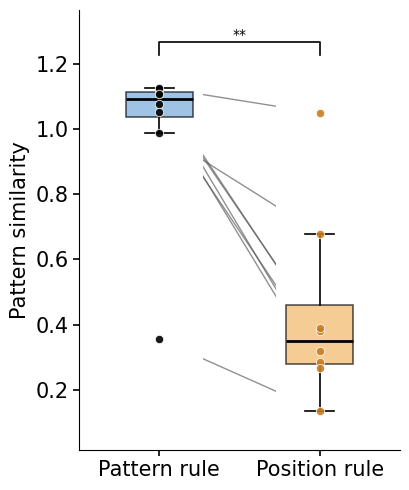

pattern_value: paired t-test, n = 8, t = 5.2261, p = 1.218e-03, **


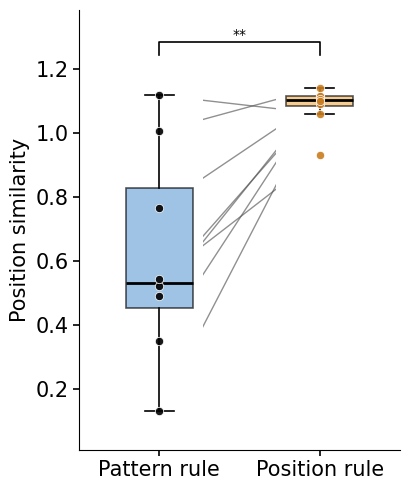

position_value: paired t-test, n = 8, t = -3.9441, p = 5.574e-03, **


In [34]:
big_dir = "../../data/HPC_2p"

df, stats_out = analyze_and_plot_all_mice_rule_corr(
    big_dir,
    group_average="by_trial",
    method="spearman",
    value_type="standardized_beta",
    plot_each_matrix=False,
    skip_error=False,
)